# Character-Level Text Generation Using LSTM

This project builds a character-level language model using TensorFlow and Keras. The model learns character patterns from *Alice's Adventures in Wonderland* and generates new text character by character.

The project covers text preprocessing, character encoding, sequence creation, LSTM-based next-character prediction, autoregressive text generation, temperature sampling, and controlled model improvement.

## 1. Dataset and Text Preprocessing

The dataset is the public-domain text of *Alice's Adventures in Wonderland* by Lewis Carroll.

The raw Gutenberg text is cleaned by removing the Gutenberg wrapper and non-story content while preserving the original characters, punctuation, capitalization, spaces, and newlines.

A contiguous corpus of approximately 80,000 characters is used for the project.

In [128]:
from pathlib import Path
import urllib.request

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

DATA_URL = "https://www.gutenberg.org/files/11/11-0.txt"
DATA_PATH = DATA_DIR / "alice_in_wonderland.txt"

urllib.request.urlretrieve(DATA_URL, DATA_PATH)

print(f"Dataset saved to: {DATA_PATH}")

Dataset saved to: data/alice_in_wonderland.txt


In [129]:
text = DATA_PATH.read_text(encoding="utf-8")

print("Text loaded successfully.")
print("Character count:", len(text))

Text loaded successfully.
Character count: 144696


In [130]:
print("Number of characters:", len(text))
print("Number of lines:", len(text.splitlines()))
print("First character:", repr(text[0]))
print("Last character:", repr(text[-1]))

Number of characters: 144696
Number of lines: 3384
First character: '*'
Last character: '\n'


In [131]:
START_MARKER = "*** START OF THE PROJECT GUTENBERG EBOOK 11 ***"
END_MARKER = "*** END OF THE PROJECT GUTENBERG EBOOK 11 ***"

start_idx = text.find(START_MARKER)
end_idx = text.find(END_MARKER)

print("Start marker index:", start_idx)
print("End marker index:", end_idx)

Start marker index: 0
End marker index: 144650


In [132]:
assert start_idx != -1, "Gutenberg start marker was not found."
assert end_idx != -1, "Gutenberg end marker was not found."
assert start_idx < end_idx, "Invalid Gutenberg boundary order."

print("Gutenberg boundaries detected successfully.")

Gutenberg boundaries detected successfully.


In [133]:
book_text = text[start_idx + len(START_MARKER):end_idx]

print("Book content extracted successfully.")
print("Raw characters:", len(text))
print("Extracted characters:", len(book_text))

Book content extracted successfully.
Raw characters: 144696
Extracted characters: 144603


In [134]:
STORY_START_MARKER = "CHAPTER I.\nDown the Rabbit-Hole"

story_start_idx = book_text.find(STORY_START_MARKER)

print("Story start index:", story_start_idx)

Story start index: 586


In [135]:
assert story_start_idx != -1, "Actual story start was not found."

print("Actual story start detected successfully.")

Actual story start detected successfully.


In [136]:
story_text = book_text[story_start_idx:]

print("Actual story extracted successfully.")
print("Story character count:", len(story_text))

Actual story extracted successfully.
Story character count: 144017


In [137]:
story_text = story_text.replace("\r\n", "\n").replace("\r", "\n")

print("Line endings normalized.")

Line endings normalized.


In [138]:
story_text = story_text.strip()

print("Boundary whitespace removed.")

Boundary whitespace removed.


In [139]:
assert story_text.startswith("CHAPTER I.\nDown the Rabbit-Hole")

print("Story begins at the first actual chapter.")

Story begins at the first actual chapter.


In [140]:
assert START_MARKER not in story_text
assert END_MARKER not in story_text

print("Gutenberg metadata successfully removed.")

Gutenberg metadata successfully removed.


In [141]:
assert not story_text.startswith("[Illustration]")
assert not story_text.startswith("Alice’s Adventures in Wonderland")
assert not story_text.startswith("by Lewis Carroll")
assert not story_text.startswith("Contents")

print("Book front matter successfully removed from the corpus beginning.")

Book front matter successfully removed from the corpus beginning.


In [142]:
raw_characters = len(text)
book_characters = len(book_text)
story_characters = len(story_text)

print("Dataset size comparison")
print("-" * 35)
print("Raw Gutenberg file:", raw_characters)
print("After Gutenberg extraction:", book_characters)
print("After front matter removal:", story_characters)
print("Total removed:", raw_characters - story_characters)

Dataset size comparison
-----------------------------------
Raw Gutenberg file: 144696
After Gutenberg extraction: 144603
After front matter removal: 144015
Total removed: 681


In [143]:
assert "\r" not in story_text

print("Newline representation is consistent.")

Newline representation is consistent.


In [144]:
TARGET_CHARS = 80_000

if len(story_text) > TARGET_CHARS:
    corpus_text = story_text[:TARGET_CHARS]

    # Move the endpoint to a paragraph boundary
    last_paragraph = corpus_text.rfind("\n\n")

    if last_paragraph > 0:
        corpus_text = corpus_text[:last_paragraph]
else:
    corpus_text = story_text

print("Final corpus prepared.")
print("Final corpus characters:", len(corpus_text))

Final corpus prepared.
Final corpus characters: 79996


In [145]:
assert 50_000 <= len(corpus_text) <= 100_000
assert corpus_text.startswith("CHAPTER I.\nDown the Rabbit-Hole")
assert START_MARKER not in corpus_text
assert END_MARKER not in corpus_text
assert "\r" not in corpus_text
assert len(corpus_text.strip()) > 0

print("All final corpus checks passed.")
print("Final corpus size:", len(corpus_text))

All final corpus checks passed.
Final corpus size: 79996


In [146]:
CLEAN_DATA_PATH = DATA_DIR / "alice_in_wonderland_clean.txt"

CLEAN_DATA_PATH.write_text(corpus_text, encoding="utf-8")

print(f"Clean corpus saved to: {CLEAN_DATA_PATH}")

Clean corpus saved to: data/alice_in_wonderland_clean.txt


In [147]:
verified_text = CLEAN_DATA_PATH.read_text(encoding="utf-8")

assert verified_text == corpus_text

print("Saved corpus reloaded successfully.")
print("Verified character count:", len(verified_text))

Saved corpus reloaded successfully.
Verified character count: 79996


In [148]:
CLEAN_DATA_PATH = DATA_DIR / "alice_in_wonderland_clean.txt"

assert CLEAN_DATA_PATH.exists(), f"Clean corpus not found: {CLEAN_DATA_PATH}"

corpus_text = CLEAN_DATA_PATH.read_text(encoding="utf-8")

print("Clean corpus loaded successfully.")
print("Character count:", len(corpus_text))

Clean corpus loaded successfully.
Character count: 79996


In [149]:
assert len(corpus_text) == 79_996
assert corpus_text.startswith("CHAPTER I.\nDown the Rabbit-Hole")

print("Corpus validation passed.")

Corpus validation passed.


## 2. Character Vocabulary and Encoding

The cleaned corpus is converted into integer character IDs using TensorFlow's `TextVectorization` layer with character-level splitting.

Each unique character receives an integer ID. The resulting sequence of IDs is used as the input representation for the LSTM.

The vocabulary contains 72 entries, including TensorFlow's special tokens.

In [150]:
import tensorflow as tf

In [151]:
vectorizer = tf.keras.layers.TextVectorization(
    split="character",
    standardize=None,
    output_mode="int"
)

print("Character-level TextVectorization created.")

Character-level TextVectorization created.


In [152]:
vectorizer.adapt([corpus_text])

print("Character vocabulary built successfully.")

Character vocabulary built successfully.


In [153]:
vocabulary = vectorizer.get_vocabulary()

print("Vocabulary size:", len(vocabulary))
print("\nFirst vocabulary entries:")

for index, token in enumerate(vocabulary[:20]):
    print(index, repr(token))

Vocabulary size: 72

First vocabulary entries:
0 ''
1 '[UNK]'
2 np.str_(' ')
3 np.str_('e')
4 np.str_('t')
5 np.str_('a')
6 np.str_('o')
7 np.str_('h')
8 np.str_('i')
9 np.str_('n')
10 np.str_('s')
11 np.str_('r')
12 np.str_('l')
13 np.str_('d')
14 np.str_('u')
15 np.str_('\n')
16 np.str_('w')
17 np.str_('g')
18 np.str_(',')
19 np.str_('c')


In [154]:
vocab_size = len(vocabulary)
print(vocab_size)

72


In [155]:
encoded_tensor = vectorizer(tf.constant([corpus_text]))

print("Corpus encoded successfully.")
print("Encoded tensor shape:", encoded_tensor.shape)

Corpus encoded successfully.
Encoded tensor shape: (1, 79996)


In [156]:
encoded_text = tf.squeeze(encoded_tensor, axis=0)

print("Encoded sequence created.")
print("Shape:", encoded_text.shape)
print("Data type:", encoded_text.dtype)

Encoded sequence created.
Shape: (79996,)
Data type: <dtype: 'int64'>


In [157]:
print("First 30 encoded character IDs:")
print(encoded_text[:30].numpy())

First 30 encoded character IDs:
[43 39 32 54 35 61 55  2 29 28 15 42  6 16  9  2  4  7  3  2 55  5 24 24
  8  4 45 39  6 12]


In [158]:
first_characters = list(corpus_text[:30])
first_ids = encoded_text[:30].numpy()

print("Character → ID")
print("-" * 30)

for character, index in zip(first_characters, first_ids):
    print(repr(character), "->", index)

Character → ID
------------------------------
'C' -> 43
'H' -> 39
'A' -> 32
'P' -> 54
'T' -> 35
'E' -> 61
'R' -> 55
' ' -> 2
'I' -> 29
'.' -> 28
'\n' -> 15
'D' -> 42
'o' -> 6
'w' -> 16
'n' -> 9
' ' -> 2
't' -> 4
'h' -> 7
'e' -> 3
' ' -> 2
'R' -> 55
'a' -> 5
'b' -> 24
'b' -> 24
'i' -> 8
't' -> 4
'-' -> 45
'H' -> 39
'o' -> 6
'l' -> 12


In [159]:
assert encoded_text.shape[0] == len(corpus_text)

print("Encoded sequence length matches corpus length.")
print("Corpus characters:", len(corpus_text))
print("Encoded tokens:", encoded_text.shape[0])

Encoded sequence length matches corpus length.
Corpus characters: 79996
Encoded tokens: 79996


In [160]:
UNK_TOKEN = "[UNK]"

assert UNK_TOKEN in vocabulary

unk_id = vocabulary.index(UNK_TOKEN)

print("Unknown token ID:", unk_id)

Unknown token ID: 1


In [161]:
unk_count = int(tf.reduce_sum(
    tf.cast(encoded_text == unk_id, tf.int32)
).numpy())

print("Unknown token count:", unk_count)

Unknown token count: 0


In [162]:
required_characters = [
    " ",
    "\n",
    ".",
    ",",
    "!",
    "?",
    "A",
    "a",
    "’",
    "“",
    "”"
]

for character in required_characters:
    assert character in vocabulary, f"Missing character: {repr(character)}"

print("All required characters are present in the vocabulary.")

All required characters are present in the vocabulary.


In [163]:
actual_characters = set(corpus_text)

# Exclude special tokens maintained by TextVectorization
vectorized_characters = set(vocabulary) - {"", "[UNK]"}

missing_characters = actual_characters - vectorized_characters

print("Actual unique characters:", len(actual_characters))
print("Characters represented by vectorizer:", len(vectorized_characters))
print("Missing characters:", len(missing_characters))

Actual unique characters: 70
Characters represented by vectorizer: 70
Missing characters: 0


In [164]:
assert len(missing_characters) == 0

print("All corpus characters are represented in the vectorizer vocabulary.")

All corpus characters are represented in the vectorizer vocabulary.


In [165]:
unicode_characters = [
    character
    for character in actual_characters
    if ord(character) > 127
]

print("Non-ASCII characters in corpus:")
print("-" * 40)

for character in sorted(unicode_characters):
    print(repr(character), "->", vocabulary.index(character))

Non-ASCII characters in corpus:
----------------------------------------
'ù' -> 70
'—' -> 38
'‘' -> 63
'’' -> 31
'“' -> 26
'”' -> 27


In [166]:
assert len(corpus_text) == 79_996
assert encoded_text.shape[0] == len(corpus_text)

assert len(missing_characters) == 0
assert unk_count == 0

assert " " in vocabulary
assert "\n" in vocabulary
assert "." in vocabulary
assert "," in vocabulary
assert "A" in vocabulary
assert "a" in vocabulary

print("All Section 3 validation checks passed.")
print()
print("Corpus length:", len(corpus_text))
print("Encoded sequence length:", encoded_text.shape[0])
print("Vocabulary size:", len(vocabulary))
print("Unknown token count:", unk_count)

All Section 3 validation checks passed.

Corpus length: 79996
Encoded sequence length: 79996
Vocabulary size: 72
Unknown token count: 0


## 3. Sequence Creation and Data Split

The encoded text is divided chronologically into training, validation, and test portions.

A sequence length of 128 characters is used. For each input sequence, the target sequence is shifted by one character so that the model learns next-character prediction at every timestep.

The data is split before sequence creation to avoid overlapping sequences crossing dataset boundaries.

In [167]:
SEQUENCE_LENGTH = 128

In [168]:
TRAIN_RATIO = 0.90
VAL_RATIO = 0.05
TEST_RATIO = 0.05

In [169]:
total_length = len(encoded_text)

train_end = int(total_length * TRAIN_RATIO)
val_end = train_end + int(total_length * VAL_RATIO)

print("Total characters:", total_length)
print("Train end:", train_end)
print("Validation end:", val_end)

Total characters: 79996
Train end: 71996
Validation end: 75995


In [170]:
train_encoded = encoded_text[:train_end]

val_encoded = encoded_text[train_end:val_end]

test_encoded = encoded_text[val_end:]

print("Train length:", len(train_encoded))
print("Validation length:", len(val_encoded))
print("Test length:", len(test_encoded))

Train length: 71996
Validation length: 3999
Test length: 4001


In [171]:
assert len(train_encoded) + len(val_encoded) + len(test_encoded) == total_length

print("All encoded characters accounted for.")

All encoded characters accounted for.


In [172]:
assert tf.reduce_all(train_encoded[-10:] == encoded_text[train_end - 10:train_end])
assert tf.reduce_all(val_encoded[:10] == encoded_text[train_end:train_end + 10])
assert tf.reduce_all(test_encoded[:10] == encoded_text[val_end:val_end + 10])

print("Chronological split boundaries verified.")

Chronological split boundaries verified.


In [173]:
def create_sequences(encoded_sequence, sequence_length):
    X = []
    y = []

    for i in range(len(encoded_sequence) - sequence_length):
        X.append(
            encoded_sequence[i:i + sequence_length]
        )
        y.append(
            encoded_sequence[i + 1:i + sequence_length + 1]
        )

    return tf.stack(X), tf.stack(y)

In [174]:
X_train, y_train = create_sequences(
    train_encoded,
    SEQUENCE_LENGTH
)

print("Training input shape:", X_train.shape)
print("Training target shape:", y_train.shape)

Training input shape: (71868, 128)
Training target shape: (71868, 128)


In [175]:
X_val, y_val = create_sequences(
    val_encoded,
    SEQUENCE_LENGTH
)

print("Validation input shape:", X_val.shape)
print("Validation target shape:", y_val.shape)

Validation input shape: (3871, 128)
Validation target shape: (3871, 128)


In [176]:
X_test, y_test = create_sequences(
    test_encoded,
    SEQUENCE_LENGTH
)

print("Test input shape:", X_test.shape)
print("Test target shape:", y_test.shape)

Test input shape: (3873, 128)
Test target shape: (3873, 128)


In [177]:
print("Training:")
print("  X:", X_train.shape)
print("  y:", y_train.shape)

print("\nValidation:")
print("  X:", X_val.shape)
print("  y:", y_val.shape)

print("\nTest:")
print("  X:", X_test.shape)
print("  y:", y_test.shape)

Training:
  X: (71868, 128)
  y: (71868, 128)

Validation:
  X: (3871, 128)
  y: (3871, 128)

Test:
  X: (3873, 128)
  y: (3873, 128)


In [178]:
assert X_train.shape[0] == len(train_encoded) - SEQUENCE_LENGTH
assert X_val.shape[0] == len(val_encoded) - SEQUENCE_LENGTH
assert X_test.shape[0] == len(test_encoded) - SEQUENCE_LENGTH

print("All sequence counts verified.")

All sequence counts verified.


In [179]:
assert X_train.shape == y_train.shape
assert X_val.shape == y_val.shape
assert X_test.shape == y_test.shape

assert X_train.shape[1] == SEQUENCE_LENGTH
assert X_val.shape[1] == SEQUENCE_LENGTH
assert X_test.shape[1] == SEQUENCE_LENGTH

print("All input-target shapes verified.")

All input-target shapes verified.


In [180]:
for X_split, y_split in [
    (X_train, y_train),
    (X_val, y_val),
    (X_test, y_test)
]:
    for i in range(min(10, X_split.shape[0])):
        assert tf.reduce_all(
            X_split[i][1:] == y_split[i][:-1]
        )

print("Input-target alignment verified for all splits.")

Input-target alignment verified for all splits.


## 4. TensorFlow Data Pipeline

The sequence pairs are converted into `tf.data.Dataset` objects and batched for training.

The training dataset is shuffled, while the validation and test datasets remain ordered. Prefetching is used to improve input pipeline efficiency.

In [181]:
BATCH_SIZE = 64

In [182]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
)

train_dataset = train_dataset.shuffle(
    buffer_size=len(X_train),
    seed=42,
    reshuffle_each_iteration=True
)

train_dataset = train_dataset.batch(
    BATCH_SIZE
)

train_dataset = train_dataset.prefetch(
    tf.data.AUTOTUNE
)

print("Training dataset created.")

Training dataset created.


In [183]:
val_dataset = tf.data.Dataset.from_tensor_slices(
    (X_val, y_val)
)

val_dataset = val_dataset.batch(
    BATCH_SIZE
)

val_dataset = val_dataset.prefetch(
    tf.data.AUTOTUNE
)

print("Validation dataset created.")

Validation dataset created.


In [184]:
test_dataset = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)
)

test_dataset = test_dataset.batch(
    BATCH_SIZE
)

test_dataset = test_dataset.prefetch(
    tf.data.AUTOTUNE
)

print("Test dataset created.")

Test dataset created.


In [185]:
print("Training dataset:")
print(train_dataset.element_spec)

print("\nValidation dataset:")
print(val_dataset.element_spec)

print("\nTest dataset:")
print(test_dataset.element_spec)

Training dataset:
(TensorSpec(shape=(None, 128), dtype=tf.int64, name=None), TensorSpec(shape=(None, 128), dtype=tf.int64, name=None))

Validation dataset:
(TensorSpec(shape=(None, 128), dtype=tf.int64, name=None), TensorSpec(shape=(None, 128), dtype=tf.int64, name=None))

Test dataset:
(TensorSpec(shape=(None, 128), dtype=tf.int64, name=None), TensorSpec(shape=(None, 128), dtype=tf.int64, name=None))


## 5. Baseline LSTM Model

The baseline model uses a simple character-level architecture:

`Input → Embedding → LSTM → Dense`

The embedding represents each character as a 64-dimensional vector. A single 128-unit LSTM processes the sequence and returns an output for every timestep. The final Dense layer predicts the probability of each character in the vocabulary.

In [186]:
EMBEDDING_DIM = 64
LSTM_UNITS = 128

In [187]:
print("Sequence length:", SEQUENCE_LENGTH)
print("Embedding dimension:", EMBEDDING_DIM)
print("LSTM units:", LSTM_UNITS)
print("Batch size:", BATCH_SIZE)

Sequence length: 128
Embedding dimension: 64
LSTM units: 128
Batch size: 64


In [188]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM
    ),

    tf.keras.layers.LSTM(
        LSTM_UNITS,
        return_sequences=True
    ),

    tf.keras.layers.Dense(
        vocab_size,
        activation="softmax"
    )
])

In [189]:
sample_inputs, sample_targets = next(iter(train_dataset))

sample_outputs = model(sample_inputs)

print("Input shape:", sample_inputs.shape)
print("Output shape:", sample_outputs.shape)

Input shape: (64, 128)
Output shape: (64, 128, 72)


In [190]:
first_prediction = sample_outputs[0, 0]

print("Prediction shape:", first_prediction.shape)
print("Probability sum:", tf.reduce_sum(first_prediction).numpy())

Prediction shape: (72,)
Probability sum: 1.0


In [191]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (64, 128, 64)          │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (64, 128, 128)         │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (64, 128, 72)          │         9,288 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,712 (440.28 KB)

 Trainable params: 112,712 (440.28 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Training Configuration and Baseline Training

The model is trained using Sparse Categorical Crossentropy and the Adam optimizer.

Early stopping, model checkpointing, and learning-rate reduction are used to control training and retain the best validation performance.

The baseline results are analyzed using validation loss, accuracy, and perplexity.

In [192]:
loss_function = tf.keras.losses.SparseCategoricalCrossentropy()

In [193]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

In [194]:
model.compile(
    optimizer=optimizer,
    loss=loss_function,
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")
    ]
)

In [195]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [196]:
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_lstm_model.keras",
    monitor="val_loss",
    save_best_only=True
)

In [197]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5
)

In [198]:
callbacks = [
    early_stopping,
    model_checkpoint,
    reduce_lr
]

In [199]:
EPOCHS = 15

In [200]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/15
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.4267 - loss: 2.0476 - val_accuracy: 0.5099 - val_loss: 1.7093 - learning_rate: 0.0010
Epoch 2/15
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.5607 - loss: 1.4956 - val_accuracy: 0.5386 - val_loss: 1.5740 - learning_rate: 0.0010
Epoch 3/15
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.6267 - loss: 1.2660 - val_accuracy: 0.5453 - val_loss: 1.5741 - learning_rate: 0.0010
Epoch 4/15
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.6749 - loss: 1.0997 - val_accuracy: 0.5412 - val_loss: 1.6522 - learning_rate: 0.0010
Epoch 5/15
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.7097 - loss: 0.9895 - val_accuracy: 0.5440 - val_loss: 1.7053 - learning_rate: 5.0000e-04


In [201]:
best_epoch = tf.argmin(history.history["val_loss"]).numpy() + 1
best_val_loss = min(history.history["val_loss"])

print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)

Best epoch: 2
Best validation loss: 1.5740277767181396


In [202]:
best_val_perplexity = tf.exp(best_val_loss).numpy()

print("Best validation perplexity:", best_val_perplexity)

Best validation perplexity: 4.8260474


## 7. Autoregressive Text Generation

After training, the model generates text one character at a time.

The generated character is appended to the input sequence and used to predict the next character. Only the most recent 128 characters are provided to the model at each step.

Temperature sampling is used to control the randomness of the generated text.

In [203]:
STARTING_TEXT = "Alice was beginning"
GENERATE_LENGTH = 300
TEMPERATURES = [0.5, 0.8, 1.0]

In [204]:
id_to_char = dict(enumerate(vocabulary))

In [205]:
print("Vocabulary size:", len(id_to_char))
print("First few mappings:")

for i in range(min(10, len(id_to_char))):
    print(i, repr(id_to_char[i]))

Vocabulary size: 72
First few mappings:
0 ''
1 '[UNK]'
2 np.str_(' ')
3 np.str_('e')
4 np.str_('t')
5 np.str_('a')
6 np.str_('o')
7 np.str_('h')
8 np.str_('i')
9 np.str_('n')


In [206]:
prompt_ids = tf.squeeze(
    vectorizer(tf.constant([STARTING_TEXT]))
).numpy()

In [207]:
print("Starting text:", STARTING_TEXT)
print("Encoded shape:", prompt_ids.shape)
print("Encoded IDs:", prompt_ids)

Starting text: Alice was beginning
Encoded shape: (19,)
Encoded IDs: [32 12  8 19  3  2 16  5 10  2 24  3 17  8  9  9  8  9 17]


In [208]:
decoded_prompt = "".join(
    id_to_char[int(token_id)]
    for token_id in prompt_ids
)

print("Original prompt:", repr(STARTING_TEXT))
print("Decoded prompt:", repr(decoded_prompt))

Original prompt: 'Alice was beginning'
Decoded prompt: 'Alice was beginning'


In [209]:
def generate_text(model, start_text, num_generate, temperature=1.0):
    generated_ids = tf.squeeze(
        vectorizer(tf.constant([start_text])),
        axis=0
    ).numpy().tolist()

    generated_text = start_text

    for _ in range(num_generate):
        input_ids = generated_ids[-SEQUENCE_LENGTH:]

        input_ids = tf.constant(
            [input_ids],
            dtype=tf.int64
        )

        predictions = model(
            input_ids,
            training=False
        )

        next_char_probs = predictions[:, -1, :]

        next_char_log_probs = tf.math.log(
            tf.clip_by_value(
                next_char_probs,
                1e-8,
                1.0
            )
        )

        next_char_log_probs = (
            next_char_log_probs / temperature
        )

        next_char_id = tf.random.categorical(
            next_char_log_probs,
            num_samples=1
        )

        next_char_id = int(
            next_char_id[0, 0].numpy()
        )

        generated_ids.append(next_char_id)

        generated_text += id_to_char[next_char_id]

    return generated_text

In [210]:
generated_text = generate_text(
    model=model,
    start_text=STARTING_TEXT,
    num_generate=GENERATE_LENGTH,
    temperature=1.0
)

print(generated_text)

Alice was beginning opt. “What’s (herpench saity cramply, and well a taige risteble! The Mourden frecking of feet
ganged to
be as it queer her sidhin of that hurried,
ands as the might that she mead I can one with you now talking the look finthing worth a himped its lime!” it was litt the vionly goingary, and wonden i


In [211]:
print("Starting text:", repr(STARTING_TEXT))
print("Generated length:", len(generated_text))
print("Requested new characters:", GENERATE_LENGTH)
print()
print(generated_text)

Starting text: 'Alice was beginning'
Generated length: 319
Requested new characters: 300

Alice was beginning opt. “What’s (herpench saity cramply, and well a taige risteble! The Mourden frecking of feet
ganged to
be as it queer her sidhin of that hurried,
ands as the might that she mead I can one with you now talking the look finthing worth a himped its lime!” it was litt the vionly goingary, and wonden i


## 8. Baseline Evaluation

The best baseline checkpoint is loaded and evaluated on the validation dataset.

The baseline generation behavior is also examined at different temperatures to understand the relationship between randomness, diversity, and text coherence.

In [212]:
best_model = tf.keras.models.load_model(
    "best_lstm_model.keras"
)

val_loss, val_accuracy = best_model.evaluate(
    val_dataset,
    verbose=0
)

print("Best model validation loss:", val_loss)
print("Best model validation accuracy:", val_accuracy)

Best model validation loss: 1.5740277767181396
Best model validation accuracy: 0.5386245250701904


In [213]:
generated_samples = {}

for temperature in TEMPERATURES:
    generated_samples[temperature] = generate_text(
        best_model,
        STARTING_TEXT,
        GENERATE_LENGTH,
        temperature=temperature
    )

    print(f"\n{'=' * 80}")
    print(f"Temperature: {temperature}")
    print(f"{'=' * 80}")
    print(generated_samples[temperature])


Temperature: 0.5
Alice was beginning to see the cair.

“I was very looked and had not a large had now anything her had not a latter the footman she had not to go be a little got to the thought this to man fance in the was not well went out of the was looked to herself, “and if I should have to the Duchess and she seemant things it sag

Temperature: 0.8
Alice was beginning to it as she can mestand the elow—on’t get to do new anx her anisher.

“I surhe larger!”

“Hery hall made in a dartury: said Alice—and the bust and to down and which as the way out of the wish I fetten she would no goesn’t get of the Footle whach her severeed into to seemed to have speaking “They s

Temperature: 1.0
Alice was beginning so iedory seamed in the chimbing itse offen to be you all
findon. “What you exended down mors rembented white coment
very coming,” Alitile begin: tree a little little take, to get uppleat! the pads in my of bebor knowling a tele you’re appreen maked “That’s no —House it was to herrey i

In [214]:
best_val_loss, best_val_accuracy = best_model.evaluate(
    val_dataset,
    verbose=0
)

best_val_perplexity = tf.exp(best_val_loss)

print(f"Validation loss: {best_val_loss:.4f}")
print(f"Validation accuracy: {best_val_accuracy:.4f}")
print(f"Validation perplexity: {best_val_perplexity:.4f}")

Validation loss: 1.5740
Validation accuracy: 0.5386
Validation perplexity: 4.8260


## 9. Model Improvement Experiments

The baseline showed signs of overfitting, with training performance continuing to improve while validation performance deteriorated.

Three controlled experiments are used to test whether regularization and smaller optimization settings improve generalization:

- **Experiment 1:** LSTM 128 + dropout 0.2
- **Experiment 2:** LSTM 128 + dropout 0.2 + learning rate 0.0005
- **Experiment 3:** LSTM 96 + dropout 0.2 + learning rate 0.0005

The same dataset, sequence length, batch size, and preprocessing pipeline are retained for all experiments.

In [215]:
# Experiment 1 Configuration

EXPERIMENT_1_LSTM_UNITS = 128
EXPERIMENT_1_DROPOUT = 0.2
EXPERIMENT_1_LEARNING_RATE = 0.001
EXPERIMENT_1_EPOCHS = 15

print("Experiment 1")
print("-" * 30)
print("LSTM units:", EXPERIMENT_1_LSTM_UNITS)
print("Dropout:", EXPERIMENT_1_DROPOUT)
print("Learning rate:", EXPERIMENT_1_LEARNING_RATE)
print("Batch size:", BATCH_SIZE)
print("Sequence length:", SEQUENCE_LENGTH)

Experiment 1
------------------------------
LSTM units: 128
Dropout: 0.2
Learning rate: 0.001
Batch size: 64
Sequence length: 128


In [216]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

experiment_1_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM
    ),
    

    tf.keras.layers.LSTM(
        EXPERIMENT_1_LSTM_UNITS,
        return_sequences=True,
        dropout=EXPERIMENT_1_DROPOUT
    ),

    tf.keras.layers.Dense(
        vocab_size,
        activation="softmax"
    )
])

experiment_1_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [217]:
experiment_1_loss = tf.keras.losses.SparseCategoricalCrossentropy()

experiment_1_optimizer = tf.keras.optimizers.Adam(
    learning_rate=EXPERIMENT_1_LEARNING_RATE
)

experiment_1_model.compile(
    optimizer=experiment_1_optimizer,
    loss=experiment_1_loss,
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

In [218]:
experiment_1_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

experiment_1_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_lstm_experiment_1.keras",
    monitor="val_loss",
    save_best_only=True
)

experiment_1_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5
)

experiment_1_callbacks = [
    experiment_1_early_stopping,
    experiment_1_checkpoint,
    experiment_1_reduce_lr
]

In [219]:
experiment_1_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [220]:
experiment_1_history = experiment_1_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EXPERIMENT_1_EPOCHS,
    callbacks=experiment_1_callbacks
)

Epoch 1/15
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.4065 - loss: 2.1218 - val_accuracy: 0.5018 - val_loss: 1.7363 - learning_rate: 0.0010
Epoch 2/15
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.5300 - loss: 1.5991 - val_accuracy: 0.5603 - val_loss: 1.5548 - learning_rate: 0.0010
Epoch 3/15
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.5795 - loss: 1.4080 - val_accuracy: 0.5683 - val_loss: 1.4975 - learning_rate: 0.0010
Epoch 4/15
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.6098 - loss: 1.2936 - val_accuracy: 0.5728 - val_loss: 1.4843 - learning_rate: 0.0010
Epoch 5/15
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.6317 - loss: 1.2121 - val_accuracy: 0.5692 - val_loss: 1.4982 - learning_rate: 0.0010
Epoch 6/15
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.6488 - loss: 1.1494 - val_accuracy: 0.5685 - val_loss: 1.5243 - learning_rate: 0.0010
Epoch 7/15
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accura

In [221]:
experiment_1_model = tf.keras.models.load_model(
    "best_lstm_experiment_1.keras"
)

experiment_1_val_loss, experiment_1_val_accuracy = (
    experiment_1_model.evaluate(
        val_dataset,
        verbose=0
    )
)

experiment_1_perplexity = tf.exp(
    experiment_1_val_loss
).numpy()

print("Experiment 1 Results")
print("-" * 30)
print(f"Validation loss: {experiment_1_val_loss:.4f}")
print(f"Validation accuracy: {experiment_1_val_accuracy:.4f}")
print(f"Validation perplexity: {experiment_1_perplexity:.4f}")

Experiment 1 Results
------------------------------
Validation loss: 1.4843
Validation accuracy: 0.5728
Validation perplexity: 4.4120


In [222]:
# Experiment 2 Configuration

EXPERIMENT_2_LSTM_UNITS = 128
EXPERIMENT_2_DROPOUT = 0.2
EXPERIMENT_2_LEARNING_RATE = 0.0005
EXPERIMENT_2_EPOCHS = 15

print("Experiment 2")
print("-" * 30)
print("LSTM units:", EXPERIMENT_2_LSTM_UNITS)
print("Dropout:", EXPERIMENT_2_DROPOUT)
print("Learning rate:", EXPERIMENT_2_LEARNING_RATE)
print("Batch size:", BATCH_SIZE)
print("Sequence length:", SEQUENCE_LENGTH)

Experiment 2
------------------------------
LSTM units: 128
Dropout: 0.2
Learning rate: 0.0005
Batch size: 64
Sequence length: 128


In [223]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

experiment_2_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM
    ),

    tf.keras.layers.LSTM(
        EXPERIMENT_2_LSTM_UNITS,
        return_sequences=True,
        dropout=EXPERIMENT_2_DROPOUT
    ),

    tf.keras.layers.Dense(
        vocab_size,
        activation="softmax"
    )
])

experiment_2_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [224]:
experiment_2_loss = tf.keras.losses.SparseCategoricalCrossentropy()

experiment_2_optimizer = tf.keras.optimizers.Adam(
    learning_rate=EXPERIMENT_2_LEARNING_RATE
)

experiment_2_model.compile(
    optimizer=experiment_2_optimizer,
    loss=experiment_2_loss,
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

In [225]:
experiment_2_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

experiment_2_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_lstm_experiment_2.keras",
    monitor="val_loss",
    save_best_only=True
)

experiment_2_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5
)

experiment_2_callbacks = [
    experiment_2_early_stopping,
    experiment_2_checkpoint,
    experiment_2_reduce_lr
]

In [226]:
experiment_2_history = experiment_2_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EXPERIMENT_2_EPOCHS,
    callbacks=experiment_2_callbacks
)

Epoch 1/15
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.3595 - loss: 2.3293 - val_accuracy: 0.4543 - val_loss: 1.9155 - learning_rate: 5.0000e-04
Epoch 2/15
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.4774 - loss: 1.8225 - val_accuracy: 0.5070 - val_loss: 1.7020 - learning_rate: 5.0000e-04
Epoch 3/15
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.5216 - loss: 1.6319 - val_accuracy: 0.5402 - val_loss: 1.5990 - learning_rate: 5.0000e-04
Epoch 4/15
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.5545 - loss: 1.5079 - val_accuracy: 0.5521 - val_loss: 1.5388 - learning_rate: 5.0000e-04
Epoch 5/15
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.5784 - loss: 1.4187 - val_accuracy: 0.5631 - val_loss: 1.5047 - learning_rate: 5.0000e-04
Epoch 6/15
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.5968 - loss: 1.3489 - val_accuracy: 0.5673 - val_loss: 1.4913 - learning_rate: 5.0000e-04
Epoch 7/15
1123/1123 ━━━━━━━━━━━━━━━━━━━

In [227]:
experiment_2_model = tf.keras.models.load_model(
    "best_lstm_experiment_2.keras"
)

experiment_2_val_loss, experiment_2_val_accuracy = (
    experiment_2_model.evaluate(
        val_dataset,
        verbose=0
    )
)

experiment_2_perplexity = tf.exp(
    experiment_2_val_loss
).numpy()

print("Experiment 2 Results")
print("-" * 30)
print(f"Validation loss: {experiment_2_val_loss:.4f}")
print(f"Validation accuracy: {experiment_2_val_accuracy:.4f}")
print(f"Validation perplexity: {experiment_2_perplexity:.4f}")

Experiment 2 Results
------------------------------
Validation loss: 1.4865
Validation accuracy: 0.5689
Validation perplexity: 4.4218


In [228]:
# Experiment 3 Configuration

EXPERIMENT_3_LSTM_UNITS = 96
EXPERIMENT_3_DROPOUT = 0.2
EXPERIMENT_3_LEARNING_RATE = 0.0005
EXPERIMENT_3_EPOCHS = 15

print("Experiment 3")
print("-" * 30)
print("LSTM units:", EXPERIMENT_3_LSTM_UNITS)
print("Dropout:", EXPERIMENT_3_DROPOUT)
print("Learning rate:", EXPERIMENT_3_LEARNING_RATE)
print("Batch size:", BATCH_SIZE)
print("Sequence length:", SEQUENCE_LENGTH)

Experiment 3
------------------------------
LSTM units: 96
Dropout: 0.2
Learning rate: 0.0005
Batch size: 64
Sequence length: 128


In [229]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

experiment_3_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM
    ),

    tf.keras.layers.LSTM(
        EXPERIMENT_3_LSTM_UNITS,
        return_sequences=True,
        dropout=EXPERIMENT_3_DROPOUT
    ),

    tf.keras.layers.Dense(
        vocab_size,
        activation="softmax"
    )
])

experiment_3_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [230]:
experiment_3_loss = tf.keras.losses.SparseCategoricalCrossentropy()

experiment_3_optimizer = tf.keras.optimizers.Adam(
    learning_rate=EXPERIMENT_3_LEARNING_RATE
)

experiment_3_model.compile(
    optimizer=experiment_3_optimizer,
    loss=experiment_3_loss,
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

In [231]:
experiment_3_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

experiment_3_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_lstm_experiment_3.keras",
    monitor="val_loss",
    save_best_only=True
)

experiment_3_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5
)

experiment_3_callbacks = [
    experiment_3_early_stopping,
    experiment_3_checkpoint,
    experiment_3_reduce_lr
]

In [232]:
experiment_3_history = experiment_3_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EXPERIMENT_3_EPOCHS,
    callbacks=experiment_3_callbacks
)

Epoch 1/15
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.3453 - loss: 2.4015 - val_accuracy: 0.4411 - val_loss: 1.9951 - learning_rate: 5.0000e-04
Epoch 2/15
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.4569 - loss: 1.9052 - val_accuracy: 0.4946 - val_loss: 1.7796 - learning_rate: 5.0000e-04
Epoch 3/15
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.5036 - loss: 1.7070 - val_accuracy: 0.5219 - val_loss: 1.6676 - learning_rate: 5.0000e-04
Epoch 4/15
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.5333 - loss: 1.5875 - val_accuracy: 0.5390 - val_loss: 1.5984 - learning_rate: 5.0000e-04
Epoch 5/15
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.5538 - loss: 1.5081 - val_accuracy: 0.5497 - val_loss: 1.5536 - learning_rate: 5.0000e-04
Epoch 6/15
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.5699 - loss: 1.4473 - val_accuracy: 0.5585 - val_loss: 1.5231 - learning_rate: 5.0000e-04
Epoch 7/15
1123/1123 ━━━━━━━━━━━━━━━━━━━

In [233]:
experiment_3_model = tf.keras.models.load_model(
    "best_lstm_experiment_3.keras"
)

experiment_3_val_loss, experiment_3_val_accuracy = (
    experiment_3_model.evaluate(
        val_dataset,
        verbose=0
    )
)

experiment_3_perplexity = tf.exp(
    experiment_3_val_loss
).numpy()

print("Experiment 3 Results")
print("-" * 30)
print(f"Validation loss: {experiment_3_val_loss:.4f}")
print(f"Validation accuracy: {experiment_3_val_accuracy:.4f}")
print(f"Validation perplexity: {experiment_3_perplexity:.4f}")

Experiment 3 Results
------------------------------
Validation loss: 1.4991
Validation accuracy: 0.5718
Validation perplexity: 4.4777


## 10. Final Model Selection and Results

The baseline and fine-tuned models are compared using validation loss, validation accuracy, and perplexity.

Experiment 1 is selected as the final model because it provides the strongest overall combination of validation performance and generated-text quality.

The final model uses a 64-dimensional embedding, a 128-unit LSTM with 0.2 dropout, and an Adam learning rate of 0.001.

In [234]:
results = {
    "Baseline": {
        "val_loss": float(best_val_loss),
        "val_accuracy": float(best_val_accuracy),
        "perplexity": float(best_val_perplexity)
    },
    "Experiment 1": {
        "val_loss": float(experiment_1_val_loss),
        "val_accuracy": float(experiment_1_val_accuracy),
        "perplexity": float(experiment_1_perplexity)
    },
    "Experiment 2": {
        "val_loss": float(experiment_2_val_loss),
        "val_accuracy": float(experiment_2_val_accuracy),
        "perplexity": float(experiment_2_perplexity)
    },
    "Experiment 3": {
        "val_loss": float(experiment_3_val_loss),
        "val_accuracy": float(experiment_3_val_accuracy),
        "perplexity": float(experiment_3_perplexity)
    }
}

print(f"{'Model':<15} {'Val Loss':<12} {'Val Accuracy':<15} {'Perplexity':<12}")
print("-" * 55)

for model_name, metrics in results.items():
    print(
        f"{model_name:<15} "
        f"{metrics['val_loss']:<12.4f} "
        f"{metrics['val_accuracy']:<15.4f} "
        f"{metrics['perplexity']:<12.4f}"
    )

Model           Val Loss     Val Accuracy    Perplexity  
-------------------------------------------------------
Baseline        1.5740       0.5386          4.8260      
Experiment 1    1.4843       0.5728          4.4120      
Experiment 2    1.4865       0.5689          4.4218      
Experiment 3    1.4991       0.5718          4.4777      


In [235]:
comparison_models = {
    "Baseline": best_model,
    "Experiment 1": experiment_1_model,
    "Experiment 2": experiment_2_model,
    "Experiment 3": experiment_3_model
}

comparison_samples = {}

for model_name, current_model in comparison_models.items():

    comparison_samples[model_name] = generate_text(
        model=current_model,
        start_text=STARTING_TEXT,
        num_generate=GENERATE_LENGTH,
        temperature=0.8
    )

    print("\n" + "=" * 80)
    print(model_name)
    print("=" * 80)
    print(comparison_samples[model_name])


Baseline
Alice was beginning of she plays herself, and her only beg or enare that, (In’t little its to,” Alice was nothing the rabel, and the thought part! So I’m and did not think in the poor hell she puch good, and she was les the charge it was latter a long if all there seen bely like a
dound the pame botter again they not 

Experiment 1
Alice was beginning to herself under the bottle that they desly at she
was to well pution a face to changed to her.
Alice was
not its of silence of the house bit: you looked to up and March tale with the door, and the
leftusempered to happen to see it, and the leare the like the hall to put the Caterpillar.

“I though

Experiment 2
Alice was beginning to do your hand it delpicud it to see craze—_That_ I’m suppen and sharged at the began again, and she could not sole
of time the petch again, so she went the say took the opportunity again! No, what the Rabbit such a say when she had now at is at the
Mouse of the say down as this like a should foun

E

In [236]:
FINAL_MODEL = experiment_1_model

FINAL_TEMPERATURES = [0.5, 0.8, 1.0]

final_temperature_samples = {}

for temperature in FINAL_TEMPERATURES:
    final_temperature_samples[temperature] = generate_text(
        model=FINAL_MODEL,
        start_text=STARTING_TEXT,
        num_generate=GENERATE_LENGTH,
        temperature=temperature
    )

    print("\n" + "=" * 80)
    print(f"Temperature: {temperature}")
    print("=" * 80)
    print(final_temperature_samples[temperature])


Temperature: 0.5
Alice was beginning anything to she had not a serpent: “the began which way to much the door, and be a tried it was got down to size the house, and then which was she looked down out of the baby was by the differented the right and the house for a voice, and the same of a great to go to a side, and began with the word

Temperature: 0.8
Alice was beginning to the smouse have another at this would not inching its greet when the Lory.

Alice had found that well in a brightened it. She neght
called to her of the would going han she set the said tone, and was sparking (a little in a little
insoring to Alice seemed antwentsen the wood.

Alice renaged to b

Temperature: 1.0
Alice was beginning was looking to fuch the hall grabling itself axteptain the sitten wasth the take to head
the lessone when theed rango house, “a must be for gloves to tele ercupesider his his high?” said), “the hall one sheth squeting,
up over her
got unto
it all last should be cur
moment, and
Tered.



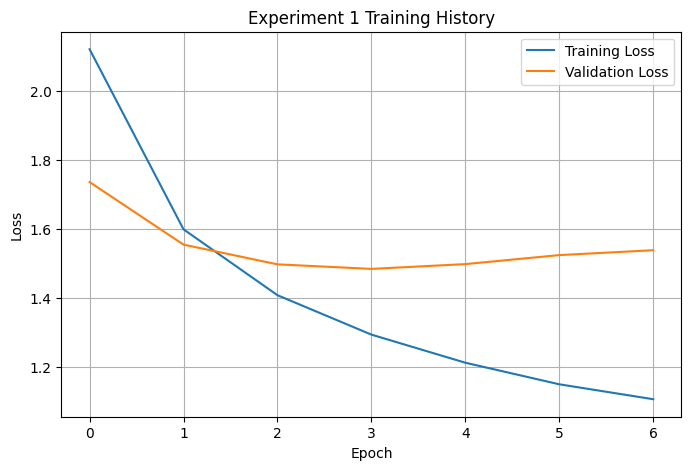

In [239]:
import matplotlib.pyplot as plt

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

plt.figure(figsize=(8, 5))

plt.plot(
    experiment_1_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    experiment_1_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 1 Training History")
plt.legend()
plt.grid(True)

plt.savefig(
    output_dir / "training_history.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [238]:
FINAL_MODEL = tf.keras.models.load_model(
    "best_lstm_experiment_1.keras"
)

test_loss, test_accuracy = FINAL_MODEL.evaluate(
    test_dataset,
    verbose=0
)

test_perplexity = tf.exp(test_loss).numpy()

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test perplexity: {test_perplexity:.4f}")

Test loss: 1.6172
Test accuracy: 0.5398
Test perplexity: 5.0391


In [237]:
from pathlib import Path

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

with open(
    output_dir / "final_temperature_samples.txt",
    "w",
    encoding="utf-8"
) as file:

    for temperature, sample in final_temperature_samples.items():
        file.write(f"Temperature: {temperature}\n")
        file.write("=" * 80 + "\n")
        file.write(sample)
        file.write("\n\n")

## 11. Conclusion

This project demonstrates character-level text generation using an LSTM with TensorFlow and Keras.

The baseline model successfully learned character-level patterns from the Alice's Adventures in Wonderland corpus, but its training behavior showed overfitting and its generated text contained malformed words and limited long-range coherence.

Three controlled experiments were performed using dropout, learning-rate changes, and a smaller LSTM configuration. Experiment 1 achieved the lowest validation loss and perplexity among the tested configurations and was selected as the final model.

Temperature sampling demonstrated the trade-off between predictability and randomness during autoregressive generation. Lower temperatures produced more conservative text, while higher temperatures introduced greater variation but also more irregular character sequences.

The final model remains limited by the relatively small training corpus, character-level representation, sequence length, and model capacity. Despite these limitations, the project demonstrates the complete workflow from text preprocessing and character encoding to sequence modeling, model training, evaluation, temperature-based generation, and controlled model improvement.